# Purpose

This notebook calculates the max difference between pumping/no pumping for each year of data availble using the tiny ensemble with 4 members.

In [5]:
#high level modules
import os
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# custom modules
fun_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/functions/"

def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

import_from_path("universals", os.path.join(fun_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test, predict_2_values_test

We need to read in the transformed test data, apply the models, and save the resictions.

In [7]:
# import test data
file_path = os.path.expanduser("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/")

# read in all the partitions
test = pd.read_csv(os.path.join(file_path, "test.csv"), sep=',')
val1 = pd.read_csv(os.path.join(file_path, "validation_1.csv"), sep=',')
val2 = pd.read_csv(os.path.join(file_path, "validation_2.csv"), sep=',')
val3 = pd.read_csv(os.path.join(file_path, "validation_3.csv"), sep=',')
val4 = pd.read_csv(os.path.join(file_path, "validation_4.csv"), sep=',')

# merge together
all_data = pd.concat([test, val1, val2, val3, val4])

# arrange the data by date
all_data['date'] = pd.to_datetime(all_data['date'])
all_data = all_data.sort_values(by='date')

# reduce to fewer variables to match tiny model names/dims
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

all_data = all_data.drop(columns = drop_cols)

all_data

,date,mean_1m_temp_degC,mean_0_5m_temp_degC,mean_1m_temp_degC_m1,mean_0_5m_temp_degC_m1,total_solar_radiation,total_solar_radiation_m1,mean_air_temp,min_air_temp,max_air_temp,...,min_air_temp_m1,max_air_temp_m1,mean_rel_hum_m1,pump_cfs_m1,mean_wind,max_wind,mean_wind_m1,max_wind_m1,nf_cfs_m1,chipmunk_cfs_m1
0,2014-06-12,-2.027604,-1.885349,-2.079576,-1.841996,1.501461,-0.711595,0.171481,-0.290257,0.226658,...,0.322665,-0.021630,-0.498715,-0.870177,0.962848,0.965474,1.391281,0.329616,2.859983,-1.838866
1,2014-06-17,-1.251083,-0.938882,-1.795259,-1.245386,1.623044,1.441737,0.482435,-0.115015,0.554796,...,-0.512483,0.121798,-1.457266,-0.870177,0.818034,0.699376,1.719709,1.443169,2.483531,-1.500496
2,2014-06-18,-1.484787,-0.887883,-1.251083,-0.938882,0.804240,1.623044,-0.029921,-0.004537,-0.212668,...,-0.115015,0.554796,-1.651711,-0.870177,1.471065,0.433277,0.818034,0.699376,2.370194,-0.983939
3,2014-06-19,-1.406999,-0.992029,-1.484787,-0.887883,1.792482,0.804240,-0.080312,-0.007500,0.081723,...,-0.004537,-0.212668,-0.664581,-0.870177,1.714791,1.142873,1.471065,0.433277,2.501947,-1.101999
4,2014-06-20,-0.825118,-0.653942,-1.406999,-0.992029,1.680758,1.792482,0.265307,-0.604337,0.650918,...,-0.007500,0.081723,-0.713461,-0.870177,0.488786,-0.243190,1.714791,1.142873,2.449165,-1.456644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,2023-09-28,-1.067653,-1.628125,-1.030254,-1.661135,0.020103,-0.079814,-0.047294,-0.701270,0.493628,...,-0.724551,0.603912,-0.954637,1.665885,-0.786947,-0.249602,-1.356095,-1.439030,-0.585884,0.823463
210,2023-09-29,-1.071186,-1.709042,-1.067653,-1.628125,-0.373159,0.020103,-0.054334,-0.282638,0.490012,...,-0.701270,0.493628,-0.978501,1.382443,-0.718912,-1.206061,-0.786947,-0.249602,-0.589674,0.834346
211,2023-09-30,-1.532343,-1.704946,-1.071186,-1.709042,-0.840149,-0.373159,-0.161169,-0.562008,0.315849,...,-0.282638,0.490012,-0.979182,1.521677,-0.460158,-0.168383,-0.718912,-1.206061,-0.593081,0.878501
212,2023-10-01,-1.646395,-1.624194,-1.532343,-1.704946,-0.958216,-0.840149,0.169382,0.224039,0.145603,...,-0.562008,0.315849,-0.590685,0.944848,-0.842414,-0.745464,-0.460158,-0.168383,-0.595761,0.844747


Z score mean/sd values

In [8]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

t_mean_1m = transform['mean'].get('mean_1m_temp_degC')
t_std_1m = transform['sd'].get('mean_1m_temp_degC')

t_mean_05m = transform['mean'].get('mean_0_5m_temp_degC')
t_std_05m = transform['sd'].get('mean_0_5m_temp_degC')

Mimic zero and max pump

In [9]:
t_pump_mean = transform["mean"].get("pump_cfs")
t_pump_sd = transform["sd"].get("pump_cfs")
zero_pump = (0 - t_pump_mean) / t_pump_sd
full_pump = (550 - t_pump_mean) / t_pump_sd

nopump = all_data.copy()
nopump["pump_cfs_m1"] = zero_pump

fullpump = all_data.copy()
fullpump["pump_cfs_m1"] = full_pump

Now we need to apply the models to the test data, but first we need to format the data for the models

In [10]:
nopump_features, nopump_labels = twotemp_labels_features_test(nopump)
fullpump_features, fullpump_labels = twotemp_labels_features_test(fullpump)

Load the models

In [11]:
# load the models
model_dir = '/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/tiny_model/dump/five_ten/'

models = [f for f in os.listdir(model_dir) if 'history' not in f]
models.sort()

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


Now we need to apply the models to the test data and get the resictions, for which we also need the standarization parameters to back calculate.

In [12]:

nopump["pred_1m_1"], nopump["pred_05m_1"] = predict_2_values_test(model_1, nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
nopump["pred_1m_2"], nopump["pred_05m_2"] = predict_2_values_test(model_2, nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
nopump["pred_1m_3"], nopump["pred_05m_3"] = predict_2_values_test(model_3, nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
nopump["pred_1m_4"], nopump["pred_05m_4"] = predict_2_values_test(model_4, nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

fullpump["pred_1m_1"], fullpump["pred_05m_1"] = predict_2_values_test(model_1, fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
fullpump["pred_1m_2"], fullpump["pred_05m_2"] = predict_2_values_test(model_2, fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
fullpump["pred_1m_3"], fullpump["pred_05m_3"] = predict_2_values_test(model_3, fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
fullpump["pred_1m_4"], fullpump["pred_05m_4"] = predict_2_values_test(model_4, fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

2025-05-22 10:51:52.183740: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Calculate the difference between no pump and pump across all years

In [13]:
nopump_preds = nopump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
fullpump_preds = fullpump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]

max_pump_change = nopump_preds - fullpump_preds
max_pump_change["date"] = all_data["date"]

max_pump_change

,pred_1m_1,pred_1m_2,pred_1m_3,pred_1m_4,pred_05m_1,pred_05m_2,pred_05m_3,pred_05m_4,date
0,-0.389539,-0.015014,-0.060201,-0.217925,-0.066277,0.230894,0.422488,0.496440,2014-06-12
1,-0.361711,-0.062256,0.041829,-0.251251,0.115752,0.423121,0.674653,0.554341,2014-06-17
2,-0.481944,-0.156970,0.089152,-0.243917,0.076649,0.535852,0.633305,0.593022,2014-06-18
3,-0.316501,-0.062271,0.038729,-0.071402,0.134691,0.666859,0.727966,0.801366,2014-06-19
4,-0.510883,-0.117018,-0.001587,-0.355535,0.062771,0.470064,0.699806,0.458947,2014-06-20
...,...,...,...,...,...,...,...,...,...
209,-0.102890,-0.273726,-0.278115,-0.192331,0.142543,0.140107,-0.225943,0.082605,2023-09-28
210,-0.127468,-0.312789,-0.322372,-0.179040,0.149292,0.152745,-0.277802,0.131425,2023-09-29
211,-0.079352,-0.234323,-0.165174,-0.171336,0.167501,0.167852,-0.122238,0.081284,2023-09-30
212,-0.082841,0.008161,0.057329,0.003032,0.139324,0.352334,0.080559,0.315727,2023-10-01


Now create a figure for these.

In [14]:
def plot_temp_model_predictions(max_pump_change, year, depth="both"):
    """
    Plot temperature model predictions for a given year and depth.
    
    Parameters:
    - max_pump_change: DataFrame with model prediction columns and a 'date' column
    - year: int, e.g., 2015
    - depth: str, one of "near-surface", "integrated", or "both"
    """
    max_pump_change["date"] = pd.to_datetime(max_pump_change["date"])
    data_year = max_pump_change[max_pump_change["date"].dt.year == year].copy()

    if depth not in ["near-surface", "integrated", "both"]:
        raise ValueError("Depth must be one of: 'near-surface', 'integrated', or 'both'")

    if depth == "both":
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)
    else:
        fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
        axes = [axes]  # make iterable

    if depth in ["near-surface", "both"]:
        ax1 = axes[0]
        ax1.axhline(0, color='black', linewidth=1, zorder=0)
        model_cols_1m = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
        for col in model_cols_1m:
            ax1.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
        data_year["ensemble_1m"] = data_year[model_cols_1m].mean(axis=1)
        ax1.plot(data_year["date"], data_year["ensemble_1m"], 
                 color='blue', linewidth=2.5, label="Ensemble Mean")
        ax1.set_ylabel("Difference\n(no pump vs full pump)")
        ax1.set_title(f"{year}: Near-Surface (1m) Temperature Models")

    if depth in ["integrated", "both"]:
        ax2 = axes[-1]  # last one in list, whether it's the only or second
        ax2.axhline(0, color='black', linewidth=1, zorder=0)
        model_cols_05m = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
        for col in model_cols_05m:
            ax2.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
        data_year["ensemble_05m"] = data_year[model_cols_05m].mean(axis=1)
        ax2.plot(data_year["date"], data_year["ensemble_05m"], 
                 color='blue', linewidth=2.5, label="Ensemble Mean")
        ax2.set_ylabel("Difference\n(no pump vs full pump)")
        ax2.set_title(f"{year}: Integrated (0–5m) Temperature Models")
        ax2.set_xlabel("Date")

    # Format x-axis labels
    for ax in axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    # External legend
    fig.legend(["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
               loc="center left", bbox_to_anchor=(0.91, 0.5), title="Models")
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.subplots_adjust(hspace=0.4)
    plt.show()


In [21]:
def facet_by_year_temp_predictions(max_pump_change, years, depth="near-surface"):
    """
    Facet temperature predictions by year in one column, x-axis is Day of Year (DOY).
    
    Parameters:
    - max_pump_change: DataFrame with 'date' column and prediction columns
    - years: list of years to include
    - depth: "near-surface" (1m) or "integrated" (0–5m)
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # Ensure datetime and compute DOY
    max_pump_change = max_pump_change.copy()
    max_pump_change["date"] = pd.to_datetime(max_pump_change["date"])
    max_pump_change["doy"] = max_pump_change["date"].dt.dayofyear

    # Choose depth-specific model columns
    if depth == "near-surface":
        model_cols = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
        title_prefix = "1m"
    elif depth == "integrated":
        model_cols = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
        title_prefix = "0–5m"
    else:
        raise ValueError("depth must be 'near-surface' or 'integrated'")

    n_years = len(years)
    fig, axes = plt.subplots(nrows=n_years, ncols=1, figsize=(10, n_years * 2.5), sharex=True, sharey=True)

    if n_years == 1:
        axes = [axes]  # Handle single subplot case

    for i, year in enumerate(years):
        ax = axes[i]
        year_data = max_pump_change[max_pump_change["date"].dt.year == year].copy()

        for col in model_cols:
            ax.plot(year_data["doy"], year_data[col], color="grey", alpha=0.5)

        year_data["ensemble_mean"] = year_data[model_cols].mean(axis=1)
        ax.plot(year_data["doy"], year_data["ensemble_mean"], color="blue", linewidth=2.5)

        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(f"{title_prefix} Temperature: {year}")
        if i == n_years - 1:
            ax.set_xlabel("Day of Year")
        if i == 0:
            ax.set_ylabel("Δ Temp (no vs full pump)")

        ax.set_xlim(150, 305)  # Optional: focus on summer DOY range (e.g., Jun 1 – Oct 31)
        ax.grid(True, alpha=0.3)

    # External legend
    fig.legend(["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
               loc="center left", bbox_to_anchor=(0.91, 0.5), title="Models")

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.subplots_adjust(hspace=0.4)
    plt.show()


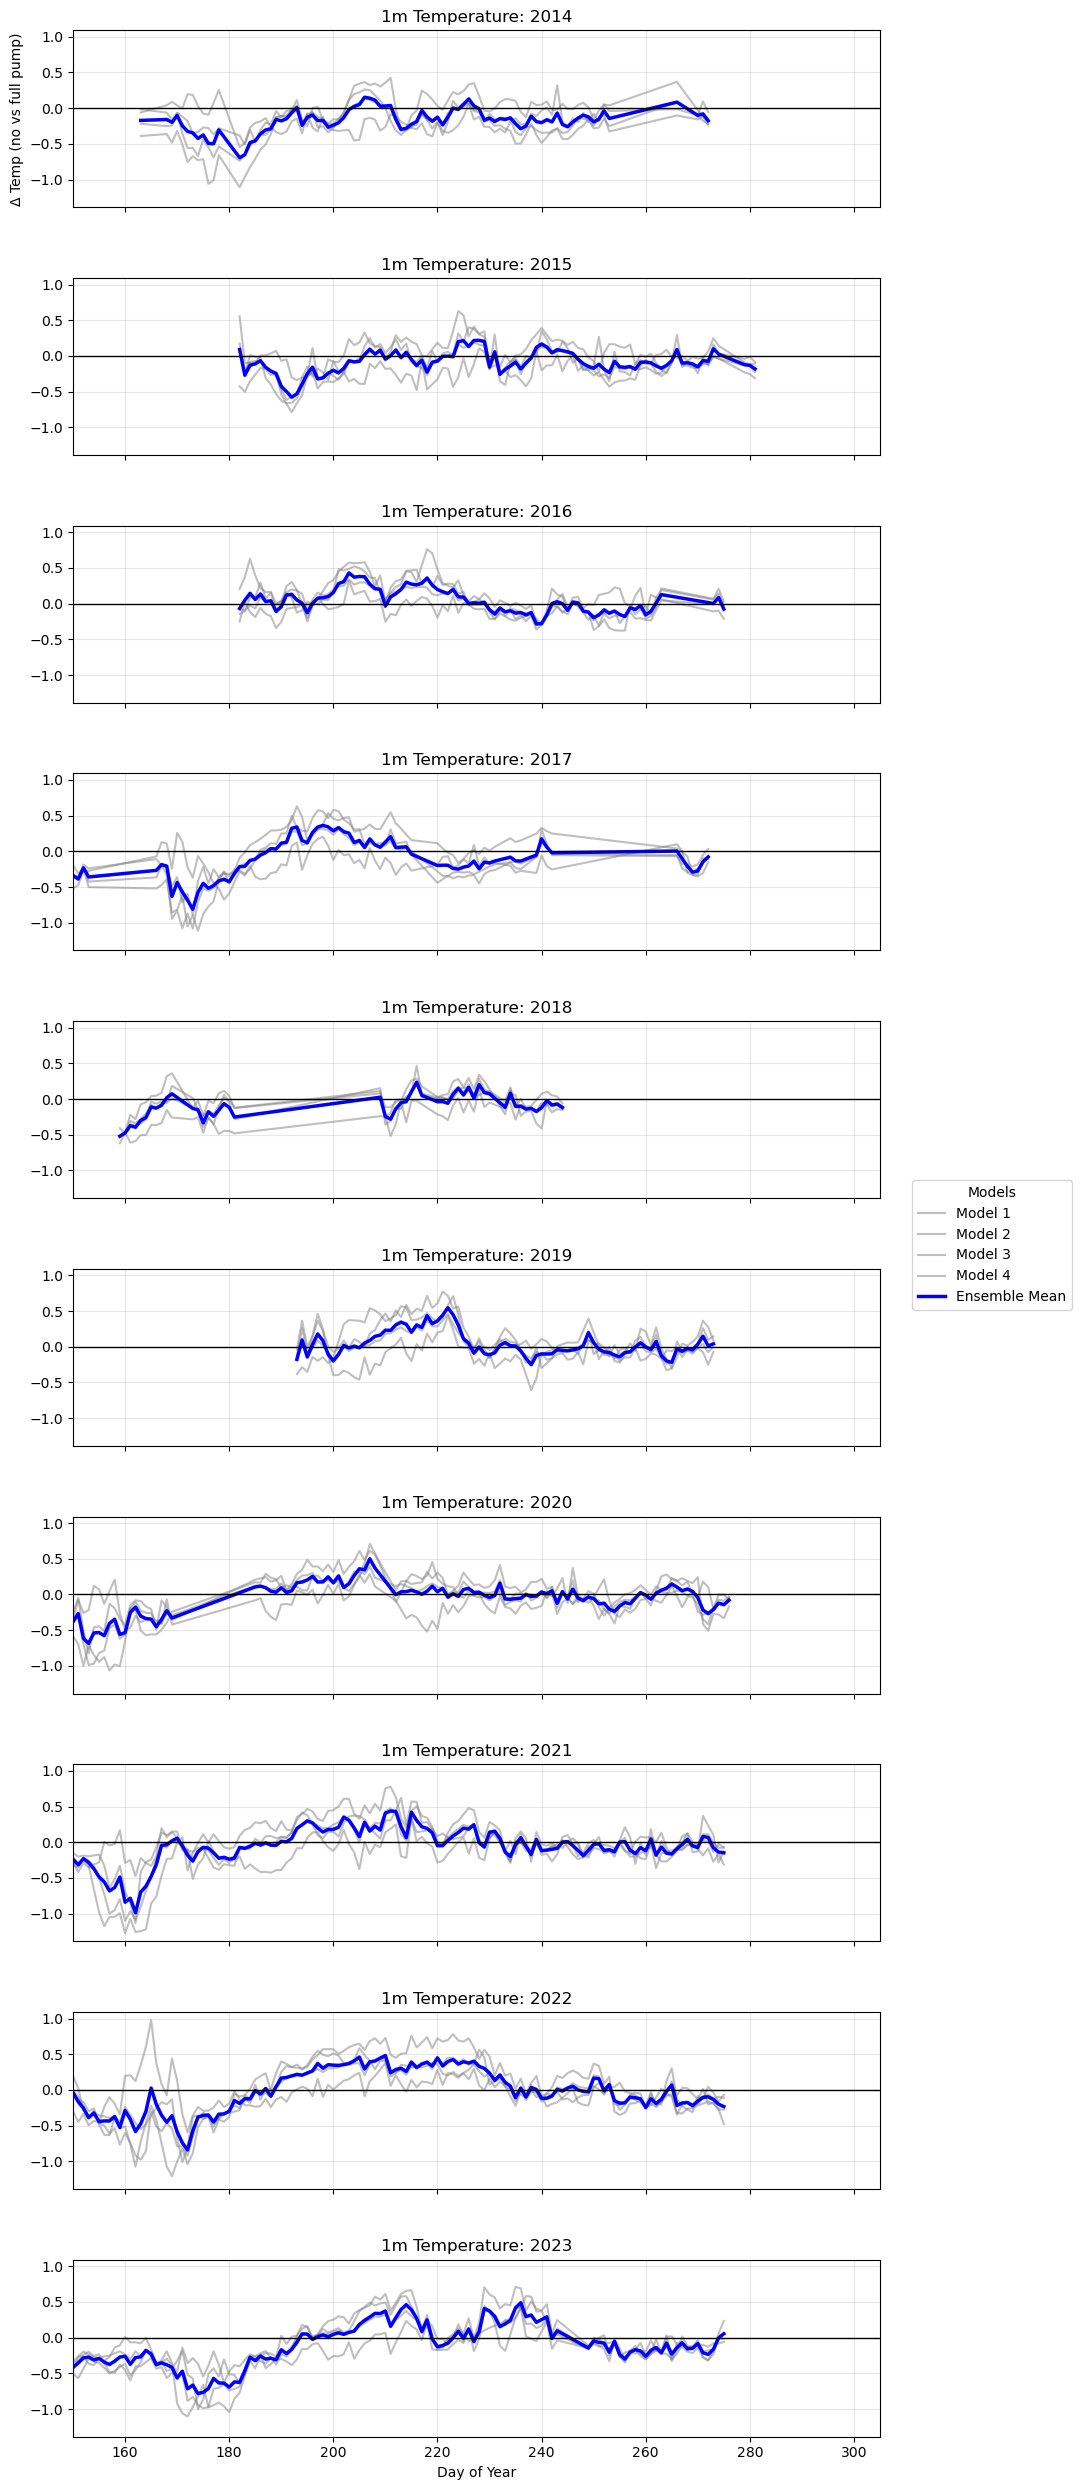

In [ ]:
years = list(range(2014, 2024))
facet_by_year_temp_predictions(max_pump_change, years, depth="near-surface")

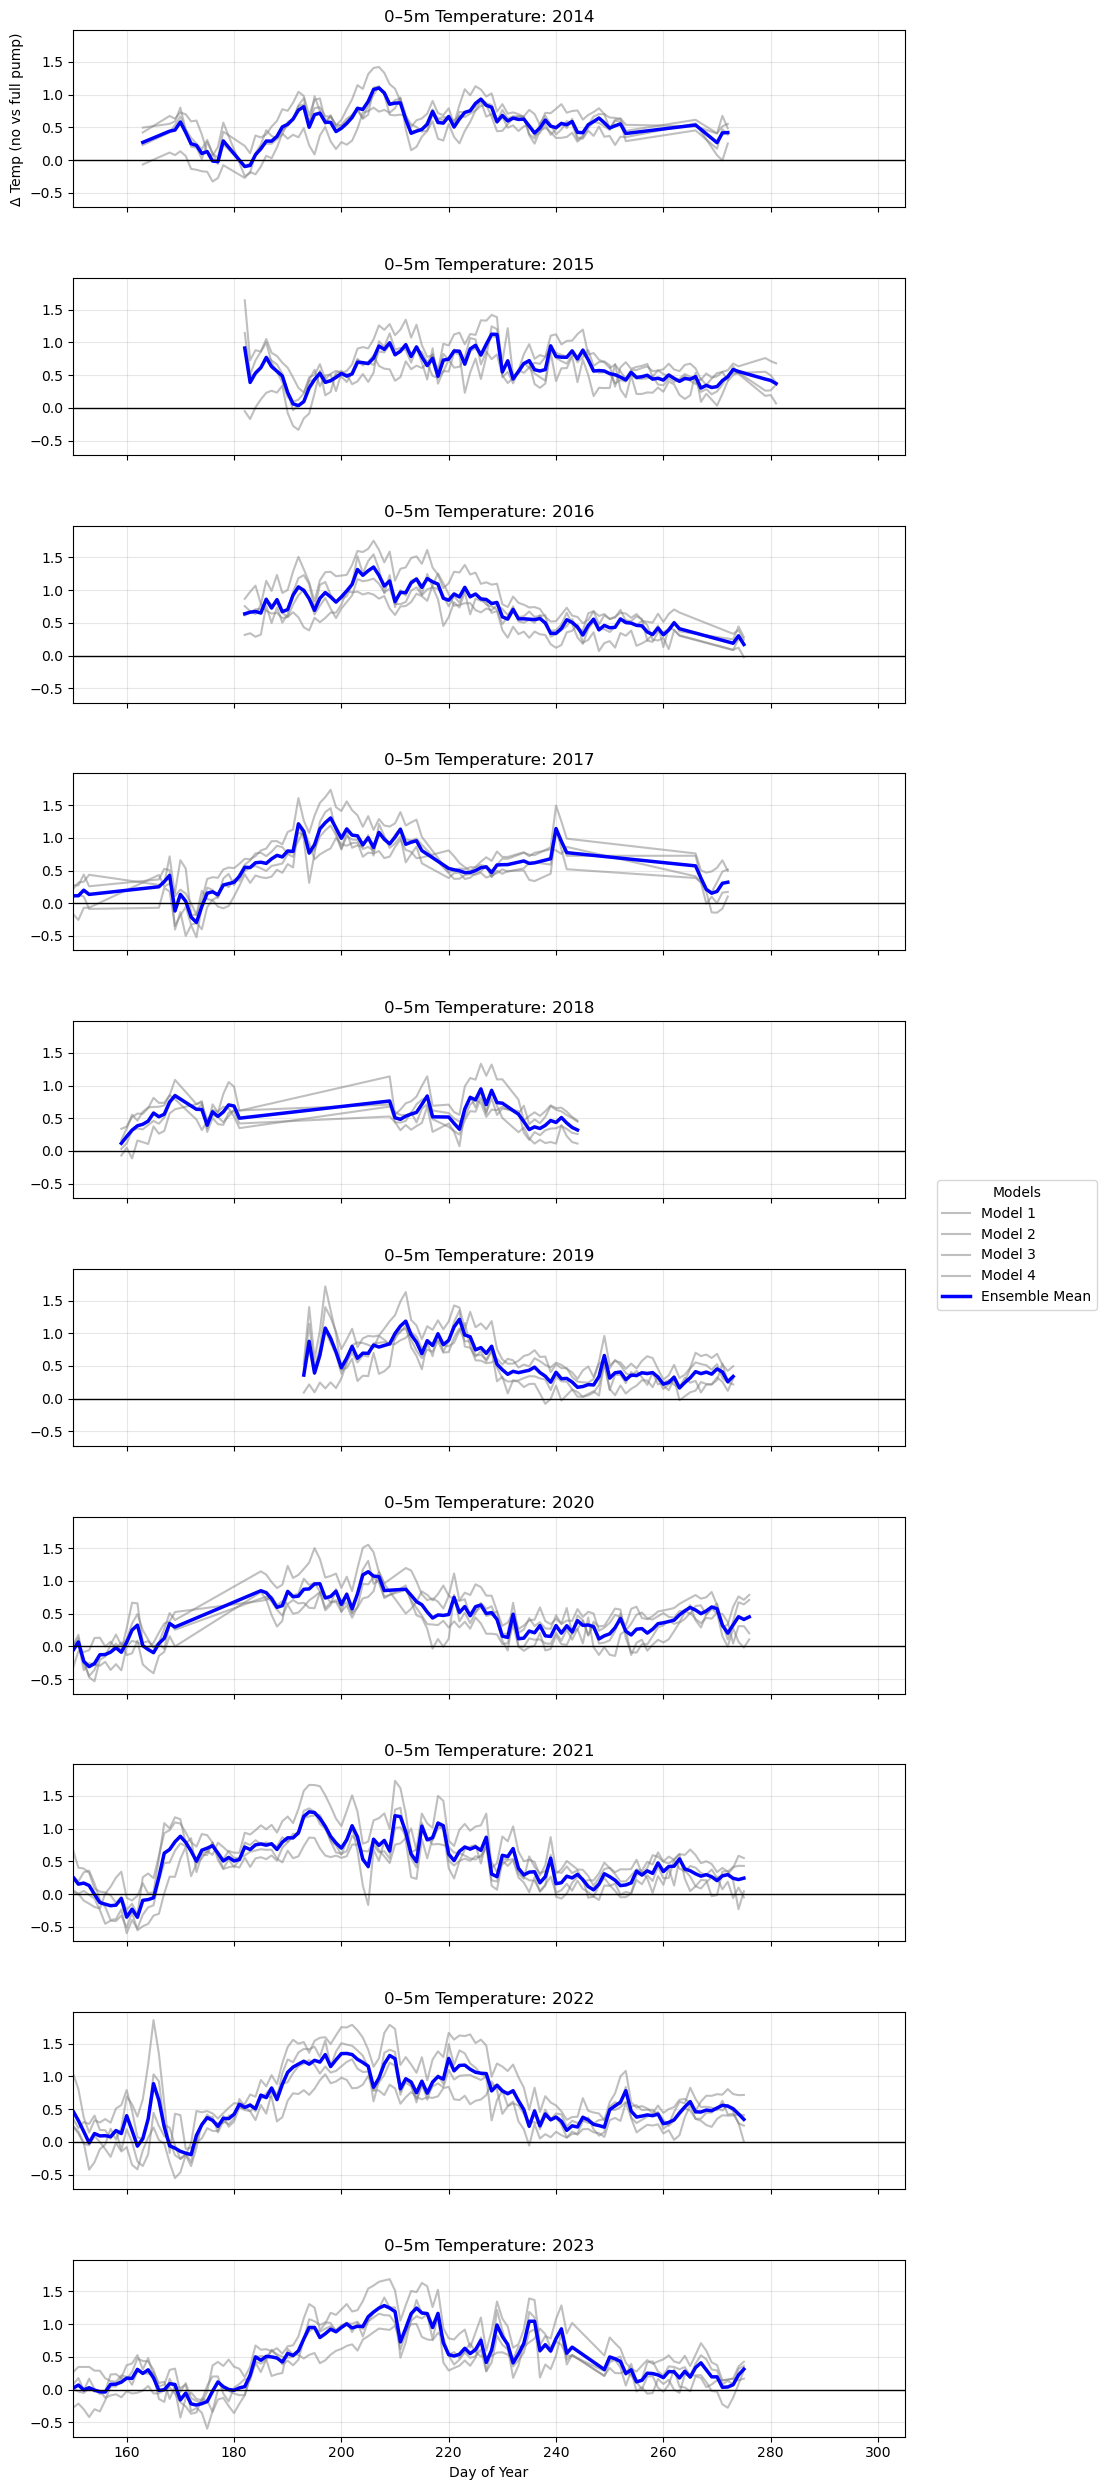

In [23]:
years = list(range(2014, 2024))
facet_by_year_temp_predictions(max_pump_change, years, depth="integrated")

In [52]:
def plot_ensemble_means_by_doy(max_pump_change, years, depth="near-surface"):
    """
    Plot only the ensemble mean for each year, aligned by DOY.

    Parameters:
    - max_pump_change: DataFrame with 'date' and prediction columns
    - years: list of years to include
    - depth: "near-surface" (1m) or "integrated" (0–5m)
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # Ensure date and doy columns
    max_pump_change = max_pump_change.copy()
    max_pump_change["date"] = pd.to_datetime(max_pump_change["date"])
    max_pump_change["doy"] = max_pump_change["date"].dt.dayofyear

    # Select model columns based on depth
    if depth == "near-surface":
        model_cols = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
        ylabel = "Change in Temp (1m)\nzero - full pumping"
    elif depth == "integrated":
        model_cols = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
        ylabel = "Change in Temp (0–5m)\nzero - full pumping"
    else:
        raise ValueError("depth must be 'near-surface' or 'integrated'")

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 5))

    # Add light yellow shaded background for July 1 (DOY 182) to Sept 11 (DOY 254)
    ax.axvspan(182, 254, color='gold', alpha=0.15, zorder=0, label="_nolegend_")

    for year in years:
        print(f"Processing year: {year}")
        # Build full date range for year
        full_dates = pd.date_range(start=f"{year}-04-15", end=f"{year}-10-10", freq="D")
        full_df = pd.DataFrame({"date": full_dates})
        full_df["doy"] = full_df["date"].dt.dayofyear

        # Merge with your actual data
        year_data = max_pump_change[max_pump_change["date"].dt.year == year].copy()
        print(f"Original data points for {year}: {len(year_data)}")

        merged = pd.merge(full_df, year_data, on="date", how="left")
        merged["doy"] = merged["date"].dt.dayofyear  # re-assign safely

        if not all(col in merged.columns for col in model_cols):
            print(f"⚠️  Skipping {year} — missing one or more model columns.")
            continue
        
        # Compute ensemble statistics
        merged["ensemble_mean"] = merged[model_cols].mean(axis=1, skipna=False)
        merged["ensemble_min"] = merged[model_cols].min(axis=1, skipna=False)
        merged["ensemble_max"] = merged[model_cols].max(axis=1, skipna=False)

        # Plot shaded area for min/max range
        ax.fill_between(
            merged["doy"],
            merged["ensemble_min"],
            merged["ensemble_max"],
            color='grey',
            alpha=0.2,
            label="_nolegend_"  # Prevents duplicate legend entries
        )

        # Plot ensemble mean line
        ax.plot(
            merged["doy"],
            merged["ensemble_mean"],
            label=str(year),
            linewidth=2
        )
        
    # Final formatting
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel("Day of Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Mean Change in Temp ({depth})")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(135, 290)  # Optional: June 1 – Oct 31
    ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


Processing year: 2014
Original data points for 2014: 88
Processing year: 2015
Original data points for 2015: 96
Processing year: 2016
Original data points for 2016: 85
Processing year: 2017
Original data points for 2017: 96
Processing year: 2018
Original data points for 2018: 52
Processing year: 2019
Original data points for 2019: 81
Processing year: 2020
Original data points for 2020: 118
Processing year: 2021
Original data points for 2021: 130
Processing year: 2022
Original data points for 2022: 129
Processing year: 2023
Original data points for 2023: 133


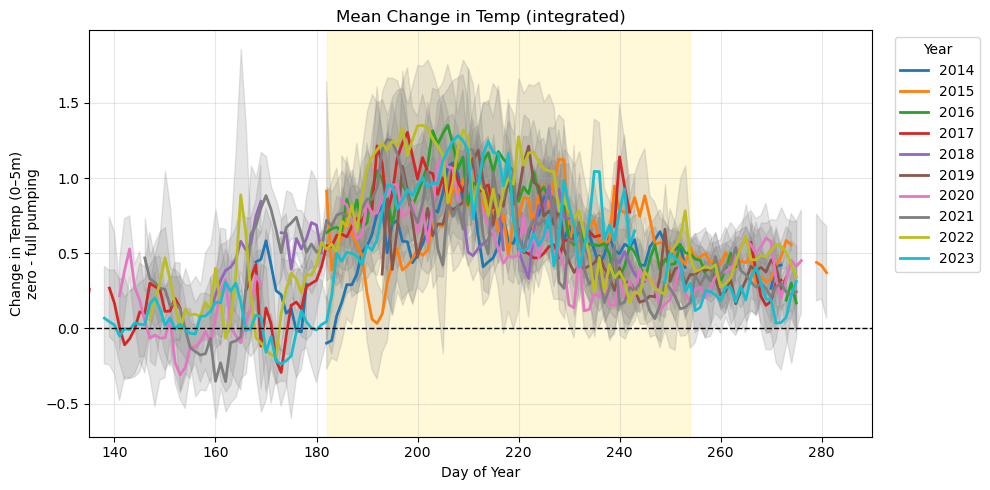

In [53]:
plot_ensemble_means_by_doy(max_pump_change, years=range(2014, 2024), depth="integrated")


Processing year: 2014
Original data points for 2014: 88
Processing year: 2015
Original data points for 2015: 96
Processing year: 2016
Original data points for 2016: 85
Processing year: 2017
Original data points for 2017: 96
Processing year: 2018
Original data points for 2018: 52
Processing year: 2019
Original data points for 2019: 81
Processing year: 2020
Original data points for 2020: 118
Processing year: 2021
Original data points for 2021: 130
Processing year: 2022
Original data points for 2022: 129
Processing year: 2023
Original data points for 2023: 133


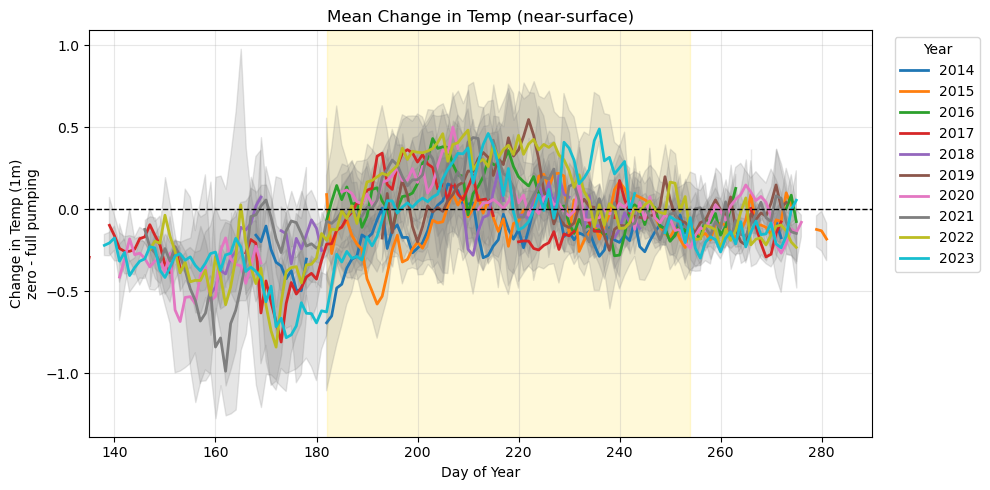

In [54]:
plot_ensemble_means_by_doy(max_pump_change, years=range(2014, 2024), depth="near-surface")


Great. Now let's calculate some statistics.

7-day rolling average of change
average change of mean across 10-year set during jul 1 - sept 11

In [66]:
# Ensure date is datetime and add DOY
seven_day = max_pump_change.copy()
seven_day["date"] = pd.to_datetime(seven_day["date"])
seven_day["doy"] = seven_day["date"].dt.dayofyear
seven_day["year"] = seven_day["date"].dt.year

# Choose the depth — near-surface (1m) or integrated (0–5m)
model_cols = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
seven_day["ensemble_mean_1m"] = seven_day[model_cols].mean(axis=1, skipna=False)
model_cols = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
seven_day["ensemble_mean_int"] = seven_day[model_cols].mean(axis=1, skipna=False)

# Compute 7-day rolling average per group (by year)
seven_day = seven_day.sort_values("date")  # Important for rolling to work
seven_day["ensemble_rolling7_1m"] = seven_day.groupby("year")["ensemble_mean_1m"].transform(
    lambda x: x.rolling(window=7, min_periods=4).mean()
)
seven_day["ensemble_rolling7_int"] = seven_day.groupby("year")["ensemble_mean_int"].transform(
    lambda x: x.rolling(window=7, min_periods=7).mean()
)

print(
min(seven_day['ensemble_rolling7_1m'].dropna()),
max(seven_day['ensemble_rolling7_1m'].dropna()),
np.mean(seven_day['ensemble_rolling7_1m'].dropna()),
min(seven_day['ensemble_rolling7_int'].dropna()),
max(seven_day['ensemble_rolling7_int'].dropna()),
np.mean(seven_day['ensemble_rolling7_int'].dropna())
)

-0.7308776404032092 0.41228343793396405 -0.06679540117674598 -0.2144390764388497 1.2900433056278946 0.5410033847634236


In [71]:
# Ensure date is datetime and add DOY
summer_df = max_pump_change.copy()
summer_df["date"] = pd.to_datetime(summer_df["date"])
summer_df["doy"] = summer_df["date"].dt.dayofyear
summer_df["year"] = summer_df["date"].dt.year
summer_df = summer_df[(summer_df["doy"] >= 182) & (summer_df["doy"] <= 254)]

# Choose the depth — near-surface (1m) or integrated (0–5m)
model_cols = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
summer_df["ensemble_mean_1m"] = summer_df[model_cols].mean(axis=1, skipna=False)
model_cols = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
summer_df["ensemble_mean_int"] = summer_df[model_cols].mean(axis=1, skipna=False)

# Group by year and calculate the mean ensemble value for each year
summer_means_1m = summer_df.groupby("year")["ensemble_mean_1m"].mean()
summer_means_int = summer_df.groupby("year")["ensemble_mean_int"].mean()

# Get the overall 10-year average and standard deviation
avg_summer_change_1m = summer_means_1m.mean()
avg_summer_change_int = summer_means_int.mean()

summer_change_sd_1m = summer_means_1m.std()
summer_change_sd_int = summer_means_int.std()

print(avg_summer_change_1m, avg_summer_change_int,
      summer_change_sd_1m, summer_change_sd_int)


0.027275078436205913 0.6778926629836322 0.09333775195373656 0.10434155723526337
